<div style="text-align: left;">
    <img src="../images/Virtuelle_Hochschule_Bayern_logo.svg" alt="ZenBite Picture" style="width: 20%; max-width: 20%; margin-top: 30px; margin-bottom: 20px; float: left;">
    <div style="clear: both;"></div>
</div>

<div class='bar_title'></div>

<span style="color: #E59635; font-size: 56px;">Data-Driven Supply Chain Management</span>

## Session 2b - Assignment 

<br>

<span style="color: #7F7F7F;">*Data-Driven Decisions Group (D3)*</span>

## Import Libraries

In [1]:
from dscm.session2 import *
from dscm.submit import *
from ddop2.newsvendor import SampleAverageApproximationNewsvendor
import numpy as np

In [2]:
# Just for better display of the graphs

from IPython.display import display, Javascript

disable_autoscroll_js = """
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}
"""

display(Javascript(disable_autoscroll_js))

<IPython.core.display.Javascript object>

In this assignment we will have a look at the data of a bakery that sells `breads`, 
`rolls` and `pretzels`. Let's import the dataset and have a look at the past demand.

Now let us take a look at our past demands:

In [3]:
wuerzbaeck = load_wuerzbaeck()
wuerzbaeck.target

,bread,rolls,pretzels
0,49.0,163.0,18.0
1,76.0,185.0,18.0
2,36.0,117.0,16.0
3,48.0,89.0,27.0
4,50.0,209.0,24.0
...,...,...,...
1210,11.0,89.0,18.0
1211,19.0,112.0,16.0
1212,45.0,162.0,20.0
1213,30.0,92.0,13.0


In [4]:
demand = wuerzbaeck.target
demand_bread = wuerzbaeck.target['bread']
demand_rolls = wuerzbaeck.target['rolls']
demand_pretzels = wuerzbaeck.target['pretzels']

Plot the demand for each product over time.

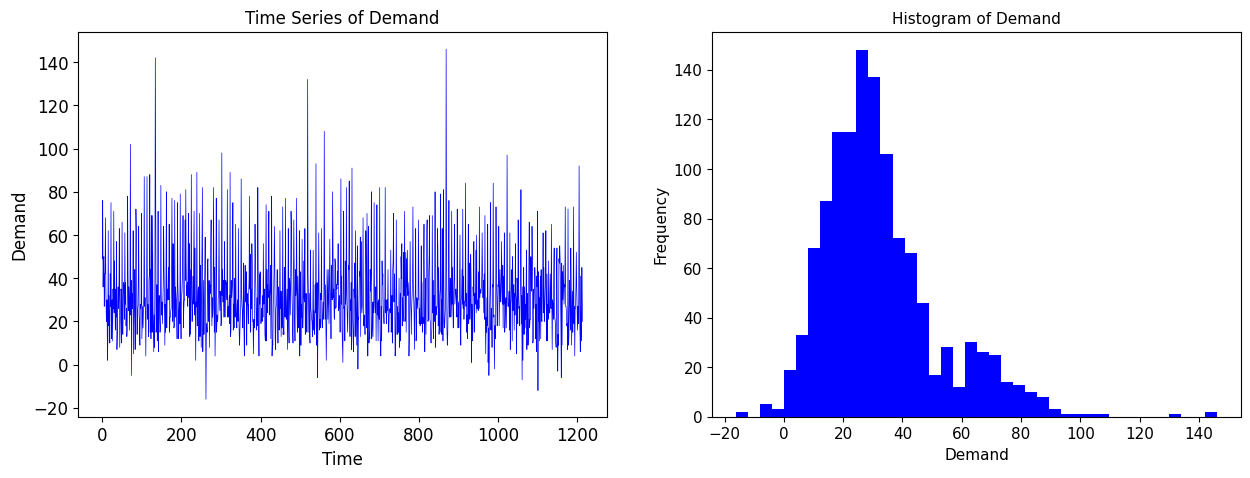

In [5]:
# plot the bread demand
plot_time_series_and_hist(demand_bread)

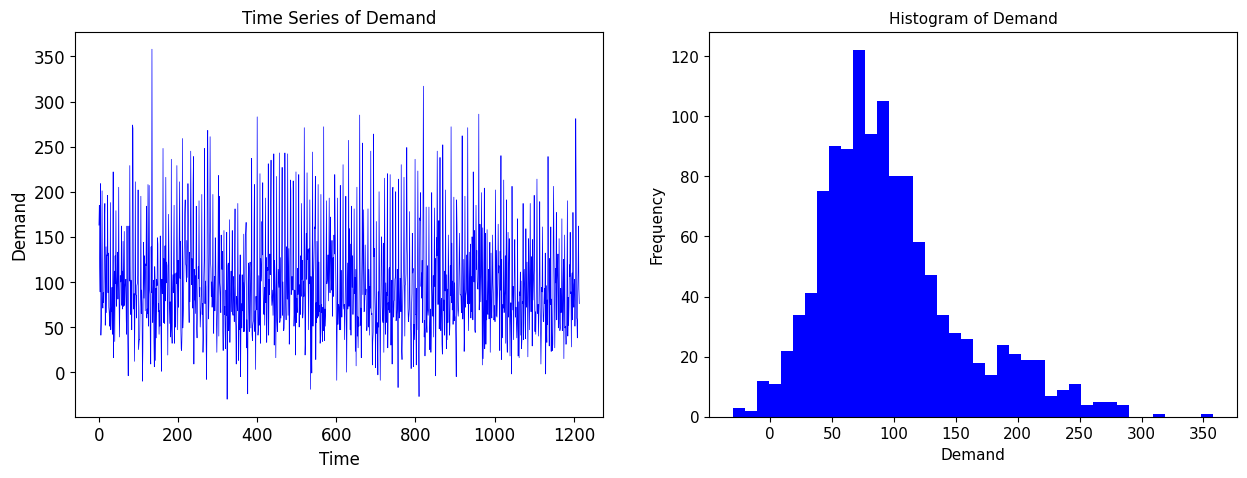

In [6]:
# plot the rolls demand
plot_time_series_and_hist(demand_rolls)

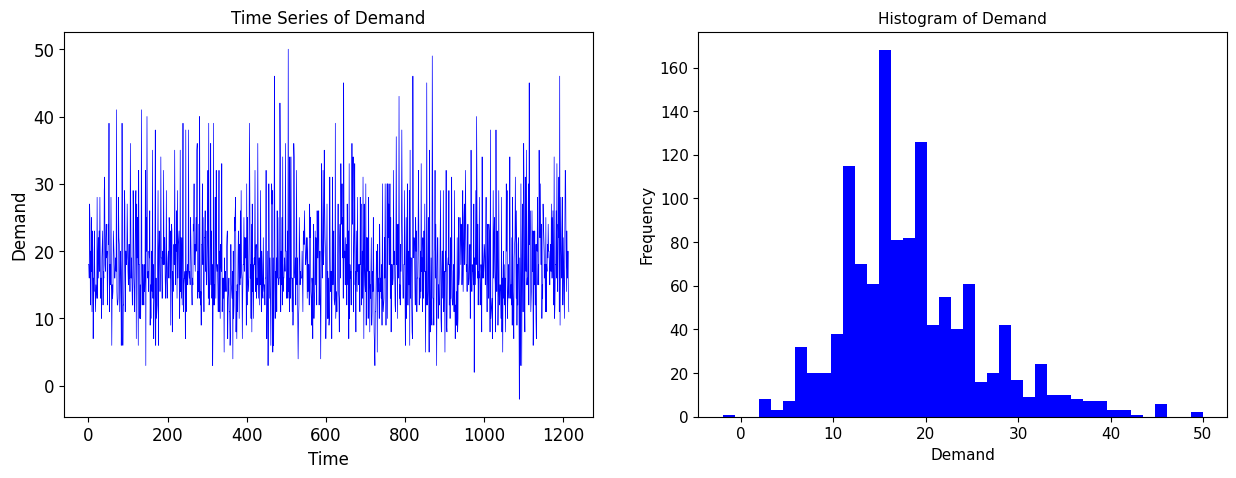

In [7]:
# plot the pretzels demand
plot_time_series_and_hist(demand_pretzels)


You are now provided with the current order decisions of the bakery for the products `breads`, `rolls` and `pretzels`.

In [8]:
order_quantities = load_order_quantities_wuerzbaeck()
order_quantities

bread        35.0
rolls       115.0
pretzels     19.0
dtype: float64

## Task 1 Service Level

### Question 1.1: What is the service level for each product of the bakery?

Tip: You can calculate the service level $\alpha$ by calculating the ratio of the number of days where the demand is lower or equal to the order quantity $q$ and the total number of days.

$\alpha = \frac{\text{numer of days where the demand is lower or equal to } q}{\text{number of total days}}$

You do not need to make a train-test split for this and the following questions. So the number of total days are equal to 1215.


In [9]:
 #Calculate the service level for rolls
q_rolls = order_quantities["rolls"]
service_level_rolls = np.mean(demand_rolls <= q_rolls)
service_level_rolls




np.float64(0.7078189300411523)

# Interpretation
Rolls demand shows moderate variability, but overall the demand pattern appears more stable compared to pretzels. 

In [10]:
# Calculate the service level for pretzels
q_pretzels = order_quantities["pretzels"]
service_level_pretzels = np.mean(demand_pretzels <= q_pretzels)
service_level_pretzels



np.float64(0.6296296296296297)

# Interpretation 
Pretzel demand appears more volatile and less predictable, with occasional spikes in demand as can also be seen in the demand graph, which may explain the lower service level. 

In [11]:
# Calculate the service level for bread
q_bread = order_quantities["bread"]
service_level_bread = np.mean(demand_bread <= q_bread)
service_level_bread

np.float64(0.6666666666666666)

# Interpretation
Bread demand appears relatively stable, although there are still some fluctuations and occasional peaks in the demand. 

Submit your answer using the `submit_answer_to_question11` function.

In [12]:
# Run this cell to submit your answers 
submit_answer_to_question11(
    bread=service_level_bread,
    rolls=service_level_rolls,
    pretzels=service_level_pretzels
)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# Task 2 Overage and Underage Costs





### Question 2.1: What is the total underage cost for each product of the bakery?

* The underage cost per unit for each product are equal to the margin of the product: $\\$
$\text{underage cost per unit} = \text{margin} = \text{price per unit} - \text{cost per unit}$

In [13]:
# Load the unit costs
unit_costs = load_unit_costs_wuerzbaeck()
unit_costs

bread       2.0
rolls       0.4
pretzels    0.6
dtype: float64

In [14]:
# load the product prices per unit
product_prices = load_prices_wuerzbaeck()
product_prices

bread       3.5
rolls       0.8
pretzels    1.2
dtype: float64

In [17]:
# Calculate the underage cost
underage_cost_bread = product_prices["bread"] - unit_costs["bread"]
underage_costs_rolls = product_prices["rolls"] - unit_costs["rolls"]
underage_cost_pretzels = product_prices["pretzels"] - unit_costs["pretzels"]

print(underage_cost_bread)
print(underage_costs_rolls)
print(underage_cost_pretzels)

1.5
0.4
0.6


# Interpretation 
As expected, breads has the highest underage cost among the three products. This is consistent with our previous observations, since bread also showed the highest and most stable demand. Therefore, bread appears to be most important product for the bakery, and stockouts would be significantly more costly compared to the other products. Pretzels also seem to be relatively more important than rolls due to their higher underage cost. 

Submit your answers using the `submit_answer_to_question21` function.

In [18]:
submit_answer_to_question21(
    bread=underage_cost_bread,
    rolls=underage_costs_rolls,
    pretzels=underage_cost_pretzels
)

NameError: name 'underage_cost_bread' is not defined

### Question 2.2: What are the overage costs for each product of the bakery?


* Overage costs are the costs of producing more than the demand. 
* As you already calculated the service level in question 1.1 and the underage costs in question 2.1, you can find the underage costs by rearranging the formula for the service level $\alpha$:
* $\alpha \cdot co = (1 - \alpha) \cdot cu$
where $co$ is the overage costs and $cu$ is the underage costs.

In [19]:
# Calculate the overage costs 
overage_cost_bread = ((1 - service_level_bread) * underage_cost_bread) / service_level_bread
overage_cost_rolls = ((1 - service_level_rolls) * underage_costs_rolls) / service_level_rolls
overage_cost_pretzels = ((1 - service_level_pretzels) * underage_cost_pretzels) / service_level_pretzels

print(overage_cost_bread)
print(overage_cost_rolls)
print(overage_cost_pretzels)

0.75
0.16511627906976745
0.3529411764705882


Submit your answers using the `submit_answer_to_question22` function.

In [20]:
submit_answer_to_question22(
    bread=overage_cost_bread,
    rolls=overage_cost_rolls,
    pretzels=overage_cost_pretzels
)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# Interpretation 
Bread has the highest overage cost (approximately 0.75), meaning that producing one additional unit of bread is significantly more expensive compared to the other products. However, bread also has by far the highest underage cost (1.5). Therefore, the bakery is willing to accept a certain level of overproduction, since stockouts of bread would result in substantial lost profits.

Rolls have the lowest overage cost (approximately 0.17) and also a relatively low underage cost (0.4). Compared to the other products, rolls therefore appear to be the least critical product for the bakery. In situations where cost reductions are necessary, rolls could potentially be deprioritized.

Pretzels can be considered a product of medium importance. They are not as critical as bread, but they appear to be relatively more important than rolls in terms of both underage and overage costs.

### Question 2.3: What is the salvage value for each product of the bakery?
* The wuerzbaeck baekery sells overproduced products at the end of the day via 
the online platform "TooGoodToGo". 
* Therefore the overage costs are equal to the difference between the unit cost and some salvage value of the product that 
takes into account the potential revenue from selling the overproduced products via "TooGoodToGo": $\\$
 $\text{overage costs} = \text{unit cost} - \text{salvage value} $



In [21]:
# Calculate the salvage value
salvage_value_bread = unit_costs["bread"] - overage_cost_bread
salvage_value_rolls = unit_costs["rolls"] - overage_cost_rolls
salvage_value_pretzels = unit_costs["pretzels"] - overage_cost_pretzels

print(salvage_value_bread)
print(salvage_value_rolls)
print(salvage_value_pretzels)

1.25
0.23488372093023258
0.24705882352941178


# Interpretation
The salvage values are consistent with the previously calculated underage and overage costs. In particular, bread has the highest salvage value (1.25), which indicates that even overproduced bread still retains a relatively high value. Therefore, producing slightly more bread may be a reasonable strategy for the bakery. In addition, higher salvage values help reduce waste and lower the effective overage cost, allowing the bakery to maintain a higher service level.

Submit your answers using the `submit_answer_to_question23` function.


In [22]:
submit_answer_to_question23(
    bread=salvage_value_bread,
    rolls=salvage_value_rolls,
    pretzels=salvage_value_pretzels
)

The answer has been saved locally. Please submit the assignment when you are done with all questions.


# Task 3 SAA Newsvendor Model

### Question 3.1: What is the optimal order quantity for each product of the bakery when the salvage value is equal to zero?
Now you assume that the bakery stops offering overproduced products via "TooGoodToGo" and the salvage value is equal to zero.
Calculate the new optimal order quantity for each product of the bakery.

* Tip: You can use the SAA Newsvendor Model to calculate the optimal order quantity for each product of the bakery. You can use the underage costs that you calculated in question 2.1 and calculate the overage costs without the salvage value.


In [23]:
# Set the new values for the underage costs
cu_bread = underage_cost_bread
cu_rolls = underage_costs_rolls
cu_pretzels = underage_cost_pretzels

co_bread = unit_costs["bread"]
co_rolls = unit_costs["rolls"]
co_pretzels = unit_costs["pretzels"]


In [24]:
# Calculate the SAA solution for the newsvendor problem for bread
saa_bread = SampleAverageApproximationNewsvendor(
    cu=cu_bread,
    co=co_bread
)
saa_bread.fit(demand_bread.to_numpy().reshape(-1, 1))
optimal_order_bread = saa_bread.predict()[0]
optimal_order_bread

array([27.])

In [25]:
# Calculate the SAA solution for the newsvendor problem for rolls
saa_rolls = SampleAverageApproximationNewsvendor(
    cu=cu_rolls,
    co=co_rolls
)
saa_rolls.fit(demand_rolls.to_numpy().reshape(-1, 1))
optimal_order_rolls = saa_rolls.predict()[0]
optimal_order_rolls

array([87.])

In [26]:
# Calculate the SAA solution for the newsvendor problem for pretzels
saa_pretzels = SampleAverageApproximationNewsvendor(
    cu=cu_pretzels,
    co=co_pretzels
)
saa_pretzels.fit(demand_pretzels.to_numpy().reshape(-1, 1))
optimal_order_pretzels = saa_pretzels.predict()[0]
optimal_order_pretzels

array([17.])

# Interpretation
The optimal order quantities decrease for all products once the salvage value is set to zero. This is expected, since overproduced products can no longer be resold via “TooGoodToGo”, making overproduction significantly more expensive. As a result, the newsvendor model becomes more conservative and recommends lower order quantities in order to reduce waste and overage costs.

Submit your answer using the `submit_answer_to_question31` function.

In [27]:
submit_answer_to_question31(
   bread=float(optimal_order_bread[0]),
   rolls=float(optimal_order_rolls[0]),
   pretzels=float(optimal_order_pretzels[0])
)

The answer has been saved locally. Please submit the assignment when you are done with all questions.
